# **CIFAR-10**

In [ ]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm

In [ ]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")

Dispositivo utilizado: cuda


# Banco de dados

In [ ]:
transform = v2.Compose([
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

100%|██████████| 170M/170M [00:31<00:00, 5.39MB/s]


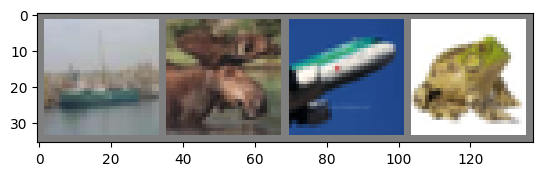

ship  deer  plane frog 


In [ ]:
def imshow(img):
  img = img / 2 + 0.5
  npimg = img.numpy()
  plt.imshow(np.transpose(npimg, (1, 2, 0)))
  plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(" ".join(f"{classes[labels[j]]:5s}" for j in range(batch_size)))

# Arquitetura (MLP)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(28*28, 128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    return x

net = Net().to(device)

# Treinamento

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.005, momentum=0.9)

In [ ]:
for epoch in tqdm(range(10), desc="Épocas"):
  running_loss = 0.0
  for i, data in enumerate(tqdm(trainloader, desc=f"Época {epoch+1} Batches")):
    inputs, labels = (data[0].to(device), data[1].to(device))

    optimizer.zero_grad()

    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if i % 2000 == 1999:
      print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}")
      running_loss = 0.0

print("Treinamento concluído")

# Salva o arquivo de pesos
NET_PATH = "./cifar_net.pt"
torch.save(net.state_dict(), NET_PATH)

Épocas:   0%|          | 0/10 [00:00<?, ?it/s]

Época 1 Batches:   0%|          | 0/12500 [00:00<?, ?it/s]

[1,  2000] loss: 2.200
[1,  4000] loss: 1.801
[1,  6000] loss: 1.604
[1,  8000] loss: 1.457
[1, 10000] loss: 1.309
[1, 12000] loss: 1.179


Época 2 Batches:   0%|          | 0/12500 [00:00<?, ?it/s]

[2,  2000] loss: 1.023
[2,  4000] loss: 0.969
[2,  6000] loss: 0.914
[2,  8000] loss: 0.858
[2, 10000] loss: 0.828
[2, 12000] loss: 0.796


...

[8,  2000] loss: 0.097
[8,  4000] loss: 0.108
[8,  6000] loss: 0.112
[8,  8000] loss: 0.121
[8, 10000] loss: 0.121
[8, 12000] loss: 0.145


Época 9 Batches:   0%|          | 0/12500 [00:00<?, ?it/s]

[9,  2000] loss: 0.068
[9,  4000] loss: 0.082
[9,  6000] loss: 0.083
[9,  8000] loss: 0.099
[9, 10000] loss: 0.096
[9, 12000] loss: 0.088


Época 10 Batches:   0%|          | 0/12500 [00:00<?, ?it/s]

[10,  2000] loss: 0.048
[10,  4000] loss: 0.049
[10,  6000] loss: 0.053
[10,  8000] loss: 0.064
[10, 10000] loss: 0.067
[10, 12000] loss: 0.065
Treinamento concluído


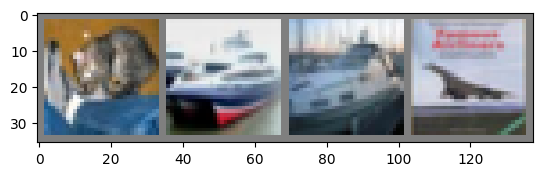

Ground Truth:  cat   ship  ship  plane


In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print("Ground Truth: ", " ".join(f"{classes[labels[j]]:5s}" for j in range(4)))

In [ ]:
net.eval()
net.load_state_dict(torch.load(NET_PATH, weights_only=True))
images = images.to(device)
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print("Previsão: ", " ".join(f"{classes[predicted[j]]:5s}" for j in range(4)))

Previsão:  cat   ship  ship  plane


In [ ]:
correct = 0
total = 0

with torch.no_grad():
  for data in testloader:
    images, labels = (data[0].to(device), data[1].to(device))
    outputs = net(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Precisão da rede em 10000 imagens de teste: {(100 * correct // total):.2f}%")

Precisão da rede em 10000 imagens de teste: 83.00%


# Arquitetura (CNN)

![ResNet18](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi0.hdslb.com%2Fbfs%2Farticle%2F3226ca546cca710f7790eb90090f40cd5d7fe48f.jpg%401192w&f=1&nofb=1&ipt=21bdc99cc3442d7387c38f40978edf4f35ba6d5ef7057b624bb8ed12053c1ff3)

## Tutorial passo a passo no [GeeksForGeeks](https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/).

In [ ]:
class BasicBlock(nn.Module):
  expansion = 1

  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                            stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                            stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels * self.expansion:
      self.shortcut = nn.Sequential(
        nn.Conv2d(
          in_channels,
          out_channels * self.expansion,
          kernel_size=1,
          stride=stride,
          bias=False
        ),
        nn.BatchNorm2d(out_channels * self.expansion)
      )

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.bn2(self.conv2(out))
    out += self.shortcut(x)
    out = F.relu(out)
    return out

class ResNet(nn.Module):
  def __init__(self, block, num_blocks, num_classes=10):
    super().__init__()
    self.in_channels = 64

    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(64)

    self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)   # 32x32
    self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)  # 16x16
    self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)  # 8x8
    self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)  # 4x4

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512 * block.expansion, num_classes)

    self._initialize_weights()

  def _make_layer(self, block, out_channels, num_blocks, stride):
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for s in strides:
      layers.append(block(self.in_channels, out_channels, s))
      self.in_channels = out_channels * block.expansion
    return nn.Sequential(*layers)

  def _initialize_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

  def forward(self, x):
    out = F.relu(self.bn1(self.conv1(x)))
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    out = self.avgpool(out)
    out = torch.flatten(out, 1)
    out = self.fc(out)
    return out

net = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(device)